# EDA World Map with Geometry

In [8]:
import os, sys
from datetime import datetime, timedelta
from collections import Counter

import numpy as np
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

from shapely import wkt

data_path = "../kgdata/edges_v3.tsv"
tmp_dir = "../tmp/"
output_dir = "../output/"

if not os.path.isdir(tmp_dir):
    os.mkdir(tmp_dir)

if not os.path.isdir(output_dir):
    os.mkdir(output_dir)

graph_cache = tmp_dir + "wikidata.sqlite3"

df = pd.read_csv(data_path, sep='\t')

In [2]:
print(df["label"].unique())

['type' 'EventId' 'DescriptionText' 'EventType' 'StartTime' 'EndTime'
 'StartDistanceFromPort_km' 'StartDistanceFromShore_km'
 'EndDistanceFromPort_km' 'EndDistanceFromShore_km' 'Location'
 'EventGeometry' 'HasParticipant' 'ValidatedBy' 'ExplainedBy'
 'HasProvenance' 'BehaviorType' 'UncertaintyNote' 'AvgSpeed_knots'
 'PatternGeometry' 'UnexplainedByWeatherOrPort' 'ObservationId' 'MMSI'
 'Lat' 'Lon' 'Speed' 'Course' 'Timestamp' 'DistanceFromPortKM'
 'DistanceFromShoreKM' 'Source' 'SSVID' 'VesselName' 'CallSign' 'Flag'
 'VesselTypeId' 'GroupType' 'HasMember' 'AsWKT' 'CentroidLat'
 'CentroidLon' 'CRS' 'PortName' 'BerthGeometry' 'TypeCode' 'TypeName'
 'subClassOf' 'FishingEffortScore' 'GearType' 'ZoneCode' 'ZoneName'
 'ZoneType' 'ZoneGeometry' 'SourceID' 'SourceName' 'SourceType'
 'SourceURL' 'MemberVessel' 'MembershipRole' 'MemberOf' 'PatternTypeID'
 'PatternTypeName' 'domain' 'range' ' type']


In [3]:
df[df["node1"] == "VesselIdentity_0"]

,node1,label,node2,edge_id
319703,VesselIdentity_0,type,VesselIdentity,VI_0
319704,VesselIdentity_0,MMSI,210316168866209,VI_1
319705,VesselIdentity_0,SSVID,412478603,VI_2
319706,VesselIdentity_0,VesselName,YUE ZHU YU YUN40019,VI_3
319707,VesselIdentity_0,CallSign,40019,VI_4
319708,VesselIdentity_0,Flag,CHN,VI_5
319709,VesselIdentity_0,VesselTypeId,VesselType_5,VI_6


In [4]:
df[(df["node1"] == "VesselType_0") & (df["label"] == "TypeName")].node2.values[0]

'BunkerVessel'

In [14]:
df[df["label"] == "HasParticipant"].node1.unique()

array(['LoiteringEvent_0', 'LoiteringEvent_1', 'LoiteringEvent_2', ...,
       'FishingEvent_328', 'FishingEvent_329', 'FishingEvent_330'],
      shape=(1698,), dtype=object)

In [5]:
geometries = df[df["label"] == "AsWKT"].node1.values
aswkt = df[df["label"] == "AsWKT"].node2.values
aswkt[0]

def extract_polygon(geometry: str):
    aswkt = df[(df["node1"] == geometry)
               & (df["label"] == "AsWKT")].node2.values[0]
    return aswkt

In [6]:
aswkt = extract_polygon("Geometry_0")

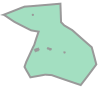

In [10]:
geom = wkt.loads(aswkt)
geom

In [20]:
def polygon_plot(geometry: str):
    fix, ax = plt.subplots(figsize=(10, 6))

    aswkt = extract_polygon(geometry)
    geom = wkt.loads(aswkt)
    
    world_map = Basemap(projection="mill",
                        lon_0=0, resolution='i', ax=ax)
    world_map.drawcoastlines()
    world_map.drawmapboundary(fill_color="lightblue")
    world_map.fillcontinents(color="lightgray", lake_color="lightblue")

    for polygon in geom.geoms:
        coords = list(polygon.exterior.coords)
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        x, y = world_map(lons, lats)
        ax.fill(x, y, color="red", alpha=0.2)
        
    plt.show()

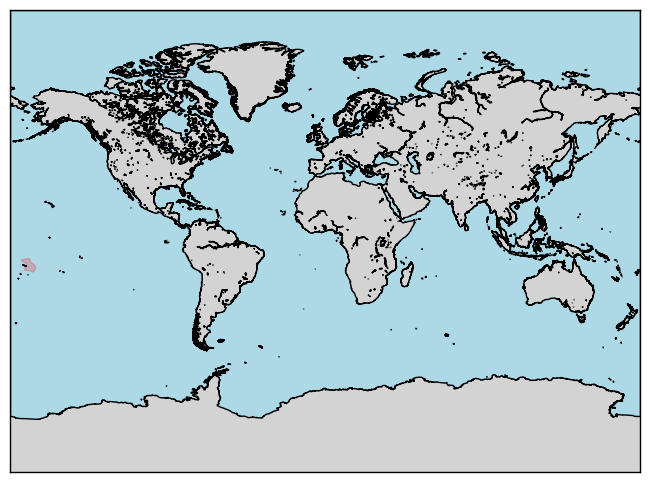

In [21]:
polygon_plot("Geometry_0")

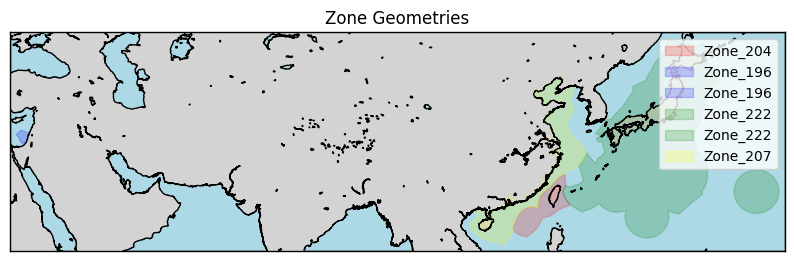

In [46]:
ZONES = ["Zone_204", "Zone_196", "Zone_222", "Zone_207"]
GEOMETRIES = ["Geometry_" + df[(df["node1"] == zone) & (df["label"] == "ZoneGeometry")].node2.values[0].split('_')[1] \
              for zone in ZONES]
ZONE_COLOR = ["red", "blue", "green", "yellow"]

def all_geom_plot(geometries: List):
    fix, ax = plt.subplots(figsize=(10, 6))

    all_lons, all_lats = [], []
    geoms = []

    for geometry in geometries:
        aswkt = extract_polygon(geometry)
        geom = wkt.loads(aswkt)
        geoms.append(geom)

        for polygon in geom.geoms:
            coords = list(polygon.exterior.coords)
            all_lons += [c[0] for c in coords]
            all_lats += [c[1] for c in coords]

    pad = 1.0
    lat_min, lat_max = min(all_lats) - pad, max(all_lats) + pad
    lon_min, lon_max = min(all_lons) - pad, max(all_lons) + pad

    world_map = Basemap(projection="mill",
                        lon_0=0,
                        llcrnrlat=lat_min, urcrnrlat=lat_max,
                        llcrnrlon=lon_min, urcrnrlon=lon_max,
                        resolution='i', ax=ax)
    world_map.drawcoastlines()
    world_map.drawmapboundary(fill_color="lightblue")
    world_map.fillcontinents(color="lightgray", lake_color="lightblue")
    
    for idx, geom in enumerate(geoms):
        for polygon in geom.geoms:
            coords = list(polygon.exterior.coords)
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            x, y = world_map(lons, lats)
            ax.fill(x, y, color=ZONE_COLOR[idx], alpha=0.2, label=ZONES[idx])
            
    ax.legend(loc="upper right")
    plt.title("Zone Geometries")
    plt.show()

all_geom_plot(GEOMETRIES)

In [54]:
zonenames = df[df["label"] == "ZoneName"].node2.values
for zonename in zonenames:
    if "philippine" in zonename.lower():
        print(zonename)

Philippine Exclusive Economic Zone


In [55]:
df[(df["label"] == "ZoneName") & (df["node2"] == "Philippine Exclusive Economic Zone")]

,node1,label,node2,edge_id
357605,Zone_169,ZoneName,Philippine Exclusive Economic Zone,Zone847


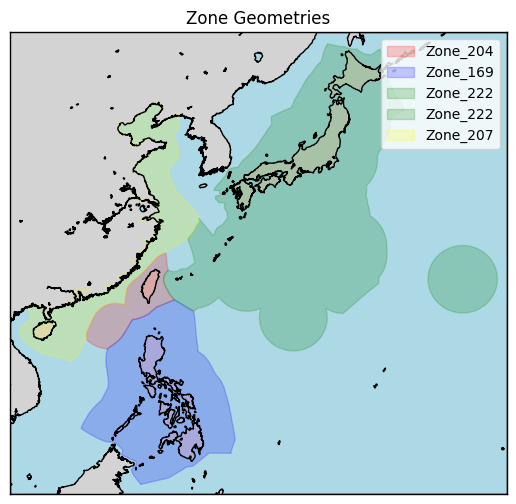

In [56]:
ZONES = ["Zone_204", "Zone_169", "Zone_222", "Zone_207"]
GEOMETRIES = ["Geometry_" + df[(df["node1"] == zone) & (df["label"] == "ZoneGeometry")].node2.values[0].split('_')[1] \
              for zone in ZONES]
ZONE_COLOR = ["red", "blue", "green", "yellow"]

all_geom_plot(GEOMETRIES)

In [57]:

ZONES = ["Zone_204", "Zone_169", "Zone_222", "Zone_207"]
GEOMETRIES = ["Geometry_" + df[(df["node1"] == zone) & (df["label"] == "ZoneGeometry")].node2.values[0].split('_')[1] \
              for zone in ZONES]
ZONE_COLOR = ["red", "blue", "green", "yellow"]
COLOR_MAP = {GEOMETRIES[i]:ZONE_COLOR[i] for i in range(len(ZONES))}

vessels = df[(df["label"] == "type") & (df["node2"] == "VesselIdentity")].node1.values

vessel2flag = {}

for vessel in vessels:
    vessel2flag[vessel] = df[(df["node1"] == vessel) &
                             (df["label"] == "Flag")].node2.values[0]

def vessel2type(vessel: str):
    vt = df[(df["node1"] == vessel) &
            (df["label"] == "VesselTypeId")].node2.values[0]
    return df[(df["node1"] == vt) & (df["label"] == "TypeName")].node2.values[0]

def vessel2event(vessel: str):
    return df[(df["label"] == "HasParticipant") &
              (df["node2"] == vessel)].node1.to_list()

def event2latlon(event: str):
    e_type = df[(df["node1"] == event) & (df["label"] == "EventType")].node2.values[0]
    zone = df[(df["node1"] == event) & (df["label"] == "Location")].node2.values[0]
    geometry = df[(df["node1"] == event) & (df["label"] == "EventGeometry")].node2.values[0]
    e_lat = float(df[(df["node1"] == geometry) & (df["label"] == "CentroidLat")].node2.values[0])
    e_lon = float(df[(df["node1"] == geometry) & (df["label"] == "CentroidLon")].node2.values[0])
    
    return (e_type, zone, e_lat, e_lon)

event_mmap = {
    "loitering": "o",
    "port_visit": "s",
    "fishing": "^"
}

zone_cmap = {
    "Zone_204": "red",
    "Zone_196": "blue",
    "Zone_222": "green",
    "Zone_207": "yellow"
}

def vessel_event_plot_with_geometry(vessel: str):
    events = vessel2event(vessel)
    events_info = list(map(lambda x: event2latlon(x), events))

    types = np.array([x[0] for x in events_info])
    zones = np.array([x[1] for x in events_info])
    lats = np.array([x[2] for x in events_info])
    lons = np.array([x[3] for x in events_info])

    lat_min, lat_max = lats.min() - 0.01, lats.max() + 0.01
    lon_min, lon_max = lons.min() - 0.01, lons.max() + 0.01

    fix, ax = plt.subplots(figsize=(10, 6))
    world_map = Basemap(projection="mill",
                        lon_0=0,
                        llcrnrlat=lat_min,
                        urcrnrlat=lat_max,
                        llcrnrlon=lon_min,
                        urcrnrlon=lon_max,
                        resolution='i',
                        ax=ax)
    world_map.drawcoastlines()
    world_map.drawmapboundary(fill_color="lightblue")
    world_map.fillcontinents(color="lightgray", lake_color="lightblue")

    x, y = world_map(lons, lats)

    title = f"{vessel2type(vessel)}:{vessel2flag[vessel]}"

    for event, marker in event_mmap.items():
        for zone, color in zone_cmap.items():
            idx = (types == event) & (zones == zone)
            world_map.scatter(
                x[idx], y[idx], marker=marker,
                color=color, s=50, edgecolors="black",
                label=f"{event}-{zone}"
            )

    for idx, geometry in enumerate(GEOMETRIES):
        aswkt = extract_polygon(geometry)
        geom = wkt.loads(aswkt)

        for polygon in geom.geoms:
            coords = list(polygon.exterior.coords)
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            x, y = world_map(lons, lats)
            ax.fill(x, y, color=ZONE_COLOR[idx], alpha=0.2)

    plt.title(title)
    plt.show()

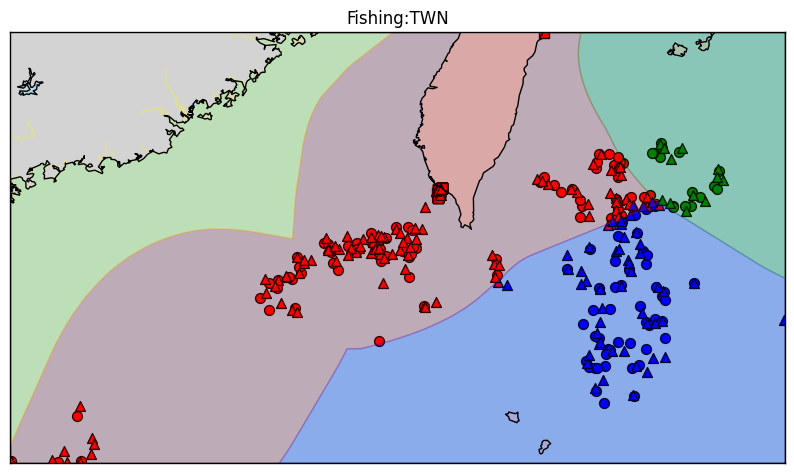

In [58]:
vessel_event_plot_with_geometry(vessels[6])

## Clustering with customize attribute

In [11]:
def event_ratio(vessel: str):
    counter = {"PortVisitEvent": 0,
               "LoiteringEvent": 0,
               "FishingEvent": 0}
    
    events = df[(df["label"] == "HasParticipant") &
                (df["node2"] == vessel)].node1.values

In [ ]:
def vessel_info(vessel: str):
    vdf = df[df["node1"] == vessel]
    y = df[(df["node1"] == vessel) &
           (df["label"] == "TypeName")].node2.values[0]
    
